In [36]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.metrics import classification_report, accuracy_score
import random
%matplotlib inline

### SDSS

In [12]:
sdss_preds_reg = np.load("preds_reg.npy")
sdss_preds_cls = np.load("preds_cls.npy")

sdss_true_reg = np.load("true_reg.npy")
sdss_true_cls = np.load("true_cls.npy")

sdss_recon_spectra = np.load("sdss_reconstructed_spectra.npy")
sdss_latent_var = np.load("sdss_latent_mu.npy")

In [13]:
sdss_mae_teff = np.mean(np.abs(sdss_preds_reg[:, 0] - sdss_true_reg[:, 0]))
sdss_mae_logg = np.mean(np.abs(sdss_preds_reg[:, 1] - sdss_true_reg[:, 1]))
sdss_mae_feh  = np.mean(np.abs(sdss_preds_reg[:, 2] - sdss_true_reg[:, 2]))

In [14]:
print(classification_report(sdss_preds_cls, sdss_true_cls))

              precision    recall  f1-score   support

           0       0.97      0.93      0.95       135
           1       0.85      0.82      0.84       151
           2       0.91      0.93      0.92       609
           3       0.85      0.86      0.85       594
           4       0.92      0.90      0.91       643
           5       0.96      0.97      0.97       564
           6       0.99      0.99      0.99       546

    accuracy                           0.92      3242
   macro avg       0.92      0.91      0.92      3242
weighted avg       0.92      0.92      0.92      3242



In [15]:
reg_sigma = np.load("../../models/reg_sigma.npy")

In [31]:
sdss_mae_teff_physical = sdss_mae_teff * reg_sigma[0]  # Kelvin
sdss_mae_logg_physical = sdss_mae_logg * reg_sigma[1]  # dex
sdss_mae_feh_physical  = sdss_mae_feh  * reg_sigma[2]  # dex

print(f"MAE Teff:   {sdss_mae_teff_physical:.2f} K")
print(f"MAE logg:   {sdss_mae_logg_physical:.4f} dex")
print(f"MAE [Fe/H]: {sdss_mae_feh_physical:.4f} dex")

MAE Teff:   352.11 K
MAE logg:   0.3243 dex
MAE [Fe/H]: 0.3274 dex


In [54]:
sdss_flux = np.load("sdss_flux.npy")

In [52]:
sdss_mae_recon = np.mean(np.abs(sdss_flux - sdss_recon_spectra))
print(sdss_mae_recon)

0.17124684


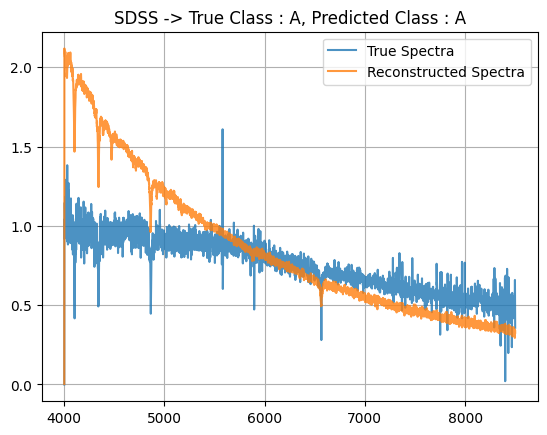

In [ ]:
LAMBDA_START = 4000
LAMBDA_END = 8500
NUM_PIXELS = 3800

wavelength_grid = np.linspace(LAMBDA_START, LAMBDA_END, NUM_PIXELS)
random_star_index_sdss = random.randint(0, 3241)
sdss_star_flux = sdss_flux[random_star_index_sdss]
sdss_recon_flux = sdss_recon_spectra[random_star_index_sdss]

sdss_true_class = ""
sdss_pred_class = ""
spectral_class_dict = {"O": 0, "B": 1, "A": 2, "F": 3, "G": 4, "K": 5, "M": 6}
for i in spectral_class_dict:
    if spectral_class_dict[i] == sdss_true_cls[random_star_index_sdss]:
        sdss_true_class = i
    if spectral_class_dict[i] == sdss_preds_cls[random_star_index_sdss]:
        sdss_pred_class = i

plt.title(f"SDSS -> True Class : {sdss_true_class}, Predicted Class : {sdss_pred_class}")
plt.grid()
plt.plot(wavelength_grid, sdss_star_flux, label = "True Spectra", alpha = 0.8)
plt.plot(wavelength_grid, sdss_recon_flux, label = "Reconstructed Spectra", alpha = 0.8)
plt.legend()
plt.show()

In [65]:
for i in spectral_class_dict:
    print(i)

O
B
A
F
G
K
M


### LAMOST (Model Transfer)

In [28]:
lamost_preds_reg = np.load("lamost_preds_reg.npy")
lamost_preds_cls = np.load("lamost_preds_cls.npy")

lamost_true_reg = np.load("lamost_true_reg.npy")
lamost_true_cls = np.load("lamost_true_cls.npy")

lamost_recon_spectra = np.load("lamost_reconstructed_spectra.npy")
lamost_flux = np.load("lamost_flux.npy")

In [29]:
lamost_mae_teff = np.mean(np.abs(lamost_preds_reg[:, 0] - lamost_true_reg[:, 0]))
lamost_mae_logg = np.mean(np.abs(lamost_preds_reg[:, 1] - lamost_true_reg[:, 1]))
lamost_mae_feh  = np.mean(np.abs(lamost_preds_reg[:, 2] - lamost_true_reg[:, 2]))

In [30]:
print(classification_report(lamost_preds_cls,lamost_true_cls))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        25
           1       0.00      0.00      0.00        37
           2       0.87      0.78      0.82      1160
           3       0.60      0.73      0.66      4227
           4       0.62      0.75      0.67      7425
           5       0.96      0.65      0.77      6899
           6       0.00      0.00      0.00        27

    accuracy                           0.71     19800
   macro avg       0.44      0.42      0.42     19800
weighted avg       0.75      0.71      0.71     19800



/home/arbiter/projects/Survey-invariant-generalization/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/arbiter/projects/Survey-invariant-generalization/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/arbiter/projects/Survey-invariant-generalization/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` 

In [32]:
lamost_mae_teff_physical = lamost_mae_teff * reg_sigma[0]  # Kelvin
lamost_mae_logg_physical = lamost_mae_logg * reg_sigma[1]  # dex
lamost_mae_feh_physical  = lamost_mae_feh  * reg_sigma[2]  # dex

print(f"MAE Teff:   {lamost_mae_teff_physical:.2f} K")
print(f"MAE logg:   {lamost_mae_logg_physical:.4f} dex")
print(f"MAE [Fe/H]: {lamost_mae_feh_physical:.4f} dex")

MAE Teff:   1254.82 K
MAE logg:   1.0033 dex
MAE [Fe/H]: 0.9088 dex


In [40]:
lamost_mae_recon = np.mean(np.abs(lamost_flux - lamost_recon_spectra))
# print(lamost_recon_spectra.shape)
print(lamost_mae_recon)

0.14479442


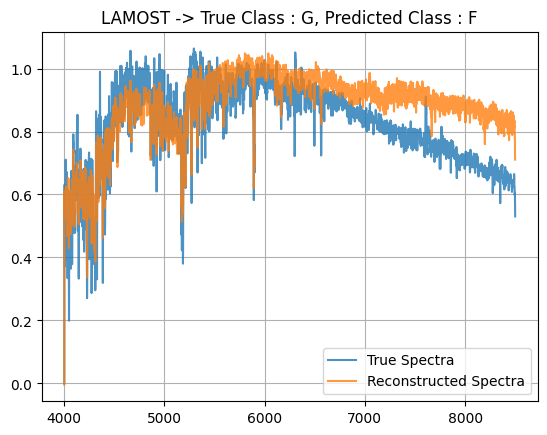

In [93]:
random_star_index_lamost = random.randint(0, 19799)
lamost_star_flux = lamost_flux[random_star_index_lamost]
lamost_star_recon = lamost_recon_spectra[random_star_index_lamost]

lamost_true_class = ""
lamost_pred_class = ""
spectral_class_dict = {"O": 0, "B": 1, "A": 2, "F": 3, "G": 4, "K": 5, "M": 6}
for i in spectral_class_dict:
    if spectral_class_dict[i] == lamost_true_cls[random_star_index_sdss]:
        lamost_true_class = i
    if spectral_class_dict[i] == lamost_preds_cls[random_star_index_sdss]:
        lamost_pred_class = i

plt.title(f"LAMOST -> True Class : {lamost_true_class}, Predicted Class : {lamost_pred_class}")
plt.grid()
plt.plot(wavelength_grid, lamost_star_flux, label = "True Spectra", alpha = 0.8)
plt.plot(wavelength_grid, lamost_star_recon, label = "Reconstructed Spectra", alpha = 0.8)
plt.legend()
plt.show()